# An Introduction to Neural Networks with PyTorch
### Adam J. Curtis

This notebook demonstrates the basics of how to code neural networks using the Python framework PyTorch.

The data used comes from a neuroimaging experiment using magnetoencephalography (MEG), where a participant viewed images from eight semantic categories: Faces, Dogs, Plants, Insects, Buildings, Cars, Tools, and Furniture. For each trial, we extract a single snapshot of brain activity recorded 165 ms after the image appeared on the screen. The dataset contains 126 features, each representing the magnetic field detected by an MEG sensor.

We will build two neural networks:

- A binary classifier to distinguish between animate (faces, dogs, plants, insects) and inanimate (buildings, cars, tools, furniture) categories.

- A multiclass classifier to predict the specific semantic category itself.

Although this is a small dataset and not ideally suited for training deep neural networks, its simplicity makes it well-suited for an introductory demonstration. It will help illustrate how neural networks learn and highlight some common challenges such as overfitting and model selection.

Let's begin by importing the necessary modules.

In [1]:
# Dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC 
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn 
from torch.optim import SGD, Adam 

And loading the data.

In [2]:
# Load MEG sensor data as raw Numpy array
raw_data = np.load("meg_pytorch_data.npy")

# Create a header for each sensor and the labels and convert to df
header = [f"s{i}" for i in range(raw_data.shape[1]-2)]
header.extend(["animacy", "category"])
raw_df = pd.DataFrame(raw_data, columns=header)

First, we will train our models on a subset of the data and then test their performance on a separate subset. Therefore, we need to split the data into a training set and a test set. We can do this by randomly selecting 25 samples per category. We can take the shape of our data and see that there are 668 samples in the training set and 200 samples in the test set each of which has 126 features (MEG sensors).

In [3]:
# Create test set by grouping the data by category and selecting 25 of each.
test_set = (
    raw_df
    .groupby('category')
    .sample(n=25, random_state=2025)
)

# Create training set defined as any items not in the test set
train_set = raw_df.loc[~raw_df.index.isin(test_set.index)]

# Isolate sensor data by removing the label columns
train_data = train_set.drop(["animacy", "category"], axis=1)
test_data = test_set.drop(["animacy", "category"], axis=1)

# Verify that the training and test sets have the expected shapes
print(f"Training set shape: {train_data.shape}")
print(f"Test set shape: {test_data.shape}")

Training set shape: (668, 126)
Test set shape: (200, 126)


Before continuing with the neural networks, let's see how a simpler model performs on the data. Specifically, let's see how a Support Vector Machine (SVM) performs. We will start by normalising the data to ensure no one feature dominates and then conduct two models. The first binary model attempts to decode the animacy of the categories. The second multiclass model tries to decode the semantic category itself. 

In [4]:
# SVM pipeline: normalise data and then classify
svm_pipeline = make_pipeline(StandardScaler(),
                             SVC())

# Fit and score SVM to decode Animacy
animacy_svm = svm_pipeline.fit(train_data, train_set["animacy"])
animacy_score = animacy_svm.score(test_data, test_set["animacy"])
print(f"Animacy SVM: {animacy_score*100:.2f}%")

# Fit and score SVM to decode Category
category_svm = svm_pipeline.fit(train_data, train_set["category"])
category_score = category_svm.score(test_data, test_set["category"])
print(f"Category SVM: {category_score*100:.2f}%")

Animacy SVM: 57.00%
Category SVM: 25.00%


We see that both SVM classifiers appear to perform above chance (above 50% and 12.5% respectively) suggesting that there is indeed information in the brain signal that distinguishes between both animacy and category information. However, could a more complex model, such as a neural network, do an even better job?

Before we build our neural networks we need to define the **Tensors**. Tensors are simply N-dimensional arrays that are passed through the network and manipulated by its operations. In deep learning frameworks like PyTorch or TensorFlow, inputs, weights, and outputs are all represented as tensors. 

In [5]:
# Normlaise the data
scaler = StandardScaler()
scaled_train = scaler.fit_transform(train_data)
scaled_test = scaler.fit_transform(test_data)

# Transform to tensors
train_tensor = torch.tensor(scaled_train).float()
test_tensor = torch.tensor(scaled_test).float()

# Class labels for the animacy network
train_animacy_labs = torch.tensor(list(train_set["animacy"])).unsqueeze(1)
test_animacy_labs = torch.tensor(list(test_set["animacy"])).unsqueeze(1)

# Number of samples and sensors (features)
n_samples, n_sensors = train_tensor.shape

In PyTorch networks are represented as user-defined classes that inherit functionality from the torch.nn.Module class. Our first network will be a network for decoding the animacy of an image named AnimacyNetwork.

When defining our network we must provide two methods: `__init__` and `forward`. 

In the `__init__` method we define the architecture of our network. We must define each layer, including the number of neurons and the operation it will perform (e.g., regression), and the activation function that will be applied to its output.

In the `forward` method we define the operations that will be applied to our data during each foward pass. 

In the AnimacyNetwork each layer performs a linear model on its input. Layer1 has 64 neruons and use a rectified linear unit as its activation function. as we are dealing with a binary categorisation problem, layer2 has a single neuron.

In [6]:
class AnimacyNetwork(nn.Module):

    def __init__(self, input_size):
        super(AnimacyNetwork, self).__init__()

        self.layer1 = nn.Linear(input_size, 64) # 64 neurons
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(64, 1) # 1 neuron

    def forward(self, input):
        # Pass input through hidden layer + ReLU activation
        x = self.relu(self.layer1(input))
        
        # Output layer2
        return self.layer2(x)

# Initialise network object
animacy_model = AnimacyNetwork(input_size=n_sensors)

Before training the model, we need to define our hyperparameters and specify the loss function and optimiser. 

On each forward pass, the model calculates its output for the current values of the weights. We can then use our **loss function** to calculate the **error** between the models predictions and the true labels in the training data. We then use the **optimiser** to calculate the gradient of the loss with respect to the weights. The gradient indicates the direction of steepest descent, the direction in which the weights should be adjusted to reduce the error. The optimiser uses our learning rate to take a step in this direction. With each iteration this will gradually modify the weights and improve the model's performance over time. 

In the example below we define the learning rate and the number of passes (n_epochs). Given that we are dealing with a binary classification problem, we will use Binary Cross Entropy with Logit Loss as our loss function. For this problem we will optimise the weights using Stochastic Gradient Descent (SGD). SGD is an algorithm that updates the weights using only a subset of the training data on each step. While this technically provides a less accurate estimate of the gradient on each step (as compared to using the full data set), it significantly improves computational efficiency. The noise introduced by using subsets can also help the model escape shallow local minima and converge more quickly toward a good solution.

In [7]:
# Define loss and optimiser
learn_rate = 0.01
n_epochs = 200
error = nn.BCEWithLogitsLoss() 
optimiser = SGD(animacy_model.parameters(), lr=learn_rate)
losses = [] # used for plotting loss curve

We are now ready to start training our model. To do this we will initialise a loop of length n_epochs. During each iteration the model will perform both a forward and a backward pass. 

During the forward pass, we apply the model’s forward method to our input data to generate predictions. We then calculate the loss by comparing these predictions to the true labels using our chosen loss function. In the backward pass, we call the built-in `backward` method to perform backpropagation and adjust our weights accordingly. 

In [8]:
for epoch in range(n_epochs):

    # ensure gradient is reset to zero for each iteration
    optimiser.zero_grad()

    # forward pass
    logits = animacy_model(train_tensor)
    loss = error(logits, train_animacy_labs)

    # backward pass
    loss.backward()

    # update weights
    optimiser.step()

    losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

Epoch 10, Loss: 0.7033
Epoch 20, Loss: 0.6995
Epoch 30, Loss: 0.6965
Epoch 40, Loss: 0.6941
Epoch 50, Loss: 0.6920
Epoch 60, Loss: 0.6903
Epoch 70, Loss: 0.6889
Epoch 80, Loss: 0.6876
Epoch 90, Loss: 0.6864
Epoch 100, Loss: 0.6853
Epoch 110, Loss: 0.6843
Epoch 120, Loss: 0.6834
Epoch 130, Loss: 0.6825
Epoch 140, Loss: 0.6816
Epoch 150, Loss: 0.6808
Epoch 160, Loss: 0.6800
Epoch 170, Loss: 0.6792
Epoch 180, Loss: 0.6785
Epoch 190, Loss: 0.6777
Epoch 200, Loss: 0.6769


Our model has now been trained! Lets assess its performance and plot the loss function.

To make predictions on the test data, we first run a forward pass through the model using torch.no_grad() to disable gradient tracking. The model outputs logits (raw predictions), which we pass through a sigmoid function to convert them into probabilities. We then apply a threshold of 0.5 to obtain binary predictions.

To assess the model’s accuracy, we compare these predictions to the true labels using accuracy_score. Finally, we plot the recorded loss values from each training epoch to visualize how the model’s error decreased over time.

Animacy network score: 56.99999999999999


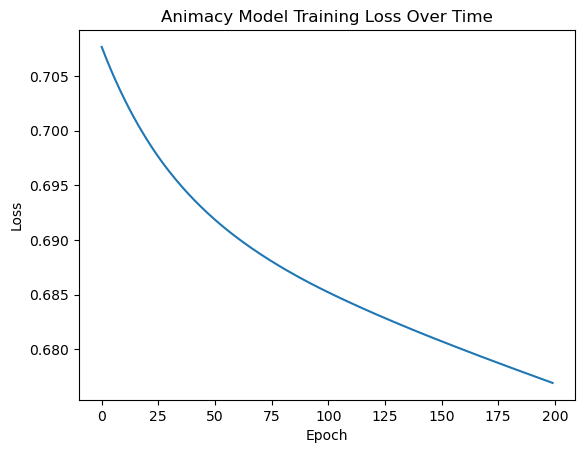

In [9]:
# Calculate probabilities
with torch.no_grad():
    logits = animacy_model(test_tensor)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float() 

# Score
animacy_network_score = accuracy_score(test_animacy_labs, preds)
print(f"Animacy network score: {animacy_network_score*100}")

# Plot
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Animacy Model Training Loss Over Time')
plt.show()

The plot above shows the training loss of the AnimacyNetwork over 200 epochs. We observe a steady decrease in loss, indicating that the model is successfully learning from the training data. The curve gradually flattens out, suggesting that the model is converging and the updates are becoming smaller over time. 

So the AnimacyNetwork seemed to do a pretty good job, but wasn't much better than our Support Vector Machine. Let's move forward with our category model and introduce some new techniques for optimising our models.

First we need to define some tensors.

In [10]:
# Label tensors for the categories
train_category_labs = torch.tensor(list(train_set["category"]))
test_category_labs = torch.tensor(list(test_set["category"]))

# CrossEntropyLoss requires labels as index integers. 
categories = list(sorted(set(train_set["category"])))
category_to_idx = {cat: idx for idx, cat in enumerate(categories)}

train_category_labs = torch.tensor([category_to_idx[c] for c in train_set["category"]])
test_category_labs = torch.tensor([category_to_idx[c] for c in test_set["category"]])

Now we define a network for the category classification called CategoryNetwork. This network takes largely the same format but with a few tweaks. 

Firstly, layer2 now has a number of neurons equal to the number of classes in our model (8), rather than the single neuron we used for binary classification. 

In addition to this we are also introducing **Dropout**. Dropout is a regularisation technique used in deep learning to prevent overfitting. During training, dropout randomly "drops" (i.e., sets to zero) a fraction of the neurons in the network on each forward pass, according to a specified probability *p*. This means that only a random subset of the network is active during each training step.

By preventing any single neuron from relying too heavily on others or becoming overly dominant in the prediction process, dropout encourages the network to learn more robust and generalizable features. 

In [11]:
class CategoryNetwork(nn.Module):

    def __init__(self, input_size, num_classes):
        super(CategoryNetwork, self).__init__()

        self.layer1 = nn.Linear(input_size, 64) # 64 neurons
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.5)
        self.layer2 = nn.Linear(64, num_classes) # num_classes neurons

    def forward(self, input):
        x = self.relu(self.layer1(input))
        x = self.dropout(x)
        x = self.layer2(x) 
        return x

# Initialise category network object
category_model = CategoryNetwork(input_size=n_sensors, num_classes=8)  

Once again we define our hyperparameters. 

Given that this is a multiclass problem we will be using Cross Entropy Loss (with no logit) as the loss function. 

This time we are also going to use a different optimiser. Instead of SGD we are going to use an algorithm called **Adaptive Moment Estimation (Adam)**. Adam introduces adaptive learning rates for each weight. If the gradient for a weight is noisy, Adam reduces the learning rate for that parameter, if the gradient is stable, Adam increases the learning rate. Adam also introduces **momentum** into the optimisation process. With momentum, rather than taking steps purely based on the current gradient, momentum allows updates to be influenced by a running average of past gradients. Together, these features help stabilize training, accelerate convergence, and reduce the likelihood of getting stuck in local minima.

In [12]:
# Define loss and optimiser
n_epochs = 100
error = nn.CrossEntropyLoss()
optimiser = Adam(category_model.parameters(), lr=learn_rate)
losses = []

Next, we are ready to train the model. 

In [13]:
for epoch in range(n_epochs):

    # ensure gradient is reset to zero for each iteration
    optimiser.zero_grad()

    # forward pass
    logits = category_model(train_tensor)
    loss = error(logits, train_category_labs)

    # backward pass
    loss.backward()

    # update weights
    optimiser.step()

    losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

Epoch 10, Loss: 1.8698
Epoch 20, Loss: 1.7007
Epoch 30, Loss: 1.5374
Epoch 40, Loss: 1.4350
Epoch 50, Loss: 1.3498
Epoch 60, Loss: 1.2318
Epoch 70, Loss: 1.2092
Epoch 80, Loss: 1.1414
Epoch 90, Loss: 1.0526
Epoch 100, Loss: 0.9698


Once again lets assess model performance and plot the loss curve.

Category network score: 24.00%


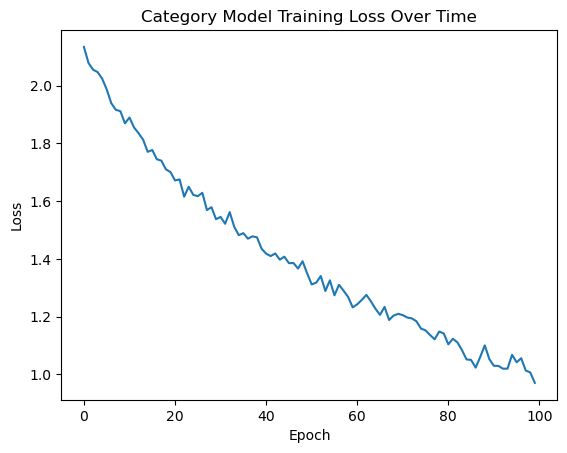

In [14]:
# Set to evaluation mode to prevent dropout during testing
category_model.eval()

# Calculate output probabilities and score
with torch.no_grad():
    logits = category_model(test_tensor)
    predicted_classes = torch.argmax(logits, dim=1)

    correct = (predicted_classes == test_category_labs).sum().item()
    total = test_category_labs.size(0)
    category_network_score = correct / total

print(f"Category network score: {category_network_score*100:.2f}%")

# Plot
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Category Model Training Loss Over Time')
plt.show()

So overall, the neural networks were able to predict both animacy and semantic category based on brain activity. However, we also observed that the performance of the networks was comparable to, and perhaps even slightly worse than, that of a simple Support Vector Machine (SVM). 

However, it is import to note that we did not attempt to optimise the hyperparameters or model architecture in this demonstration. With more effort, we could adjust the learning rate, dropout rate, and other training parameters. We could also explore more complex architectures, such as by adding additional hidden layers or using different activation functions. Together, these changes could improve the performance of the networks.

That said, deep learning models generally benefit from larger datasets. When a dataset is limited in size or the features are not highly informative, neural networks may struggle to outperform simpler models that make stronger assumptions about the data. Moreover, smaller datasets can also increase the risk of overfitting, reducing the model's ability to generalise to new data.

In this case, the inability of the neural networks to outperform the SVM likely reflects the constraints of our dataset. With more data or richer features, neural networks may show clearer advantages.